# Running Pathfinder on RADAR

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath('../Pathfinder'))

from helper_functions import *
from radar_functions import *
from pathfinder import *
from attach_grounddata import *
from add_dataflashlog import *
from clicki_tool import *

%matplotlib inline

### Loading and populating a RADAR object

Pathfinder is built around the RADAR variable. This is mainly inspired by the existing UWiBaSS pickle data structure. The data is identified via a unique *datasetID* and associated to a campaign via the *campaignID*. 

The RADAR object needs to contain: the radar echogram in any post-processed state (*rx* with size n x m), a fasttime axis represting air range bins (*fasttime* and *range_air* with size n) and a slowtime axis (*time* with size m). See Notebooks/make_RADAR.ipynb to see how to construct a suitable RADAR pickle object.

In [2]:
# This is how we load a UWiBaSS dataset into a RADAR object.
datasetID = '26_04_2024_3'
campaignID = '2024_SIOS'

# datasetID = '30_03_2022_2'
# campaignID = '2022_SIOS'


RADAR = load_RADAR(radar_type='UWiBaSS',
                   datasetID=datasetID,
                   campaignID=campaignID,
                   yaml_file="./campaigns.yaml",
                   from_scratch=True
                   )

# This is how you could open a self-created RADAR object which does not have the campaigns.yaml structure
# see Notebooks/make_RADAR.ipynb for info on how to create RADAR object

# path = "/Users/torka/NORCE_T/UWiBaSS_on_PS/2025_09_24_7.pkl"
# RADAR = load_RADAR(path=path)

active channel: rx1
Dataset 26_04_2024_3 from campaign 2024_SIOS constructed


Next we set the Pathfinder parameters and populate datafields of the RADAR object. Here you can set some flags depending on what data is available to you (flightstate, geolocation, in-situ comparison data).

In [3]:

# Setting the Pathfinder parameters
PF_parameters = {
    'a': 1,         #weight of radar image in cost function, standard: 1
    'b': 1,         #weight of (hessian) ridges in cost function, standard: 1
    'c': 2,         #weight of peak prominance in cost function, standard: 2
    'd': 2,         #weight of the localized cross-correlation, standard: 2
    'db': 0,        #depth bias term (used to have a bias towards top for top layer, bottom for bottom layer), standard: 0
    'sigma': 1,     #for blurring the cost map, 1 = no blurring, standard: 1
    'jumpiness': 2  #vertical freedom for the pathfinder (larger jumps are penalized), standard: 2
    }

# Does RADAR have flightstate data?
has_flightstate = True

# Does RADAR have geolocation data?
has_geolocation = True

# Is there in-situ data (probe/ snow profile) that you want to add? Could be for validation or to view in the clicki_tool later
add_insitu_data = True
#TODO even if add_insitu_data = False, we need to add the eps_r + uncertainty! Best derived by providing a density?

# This is a UWiBaSS specific flag. Auxilliary data is added from the ardupilot dataflashlogs and some processing is done there
check_dataflashlog = True 

#TODO: Even if add_insitu_data = False, we return the 4 vars, this is of course not nice and pretty much unintuitive
RADAR, df_MP, df_SP, dict_SP = populate_datafields(RADAR,
                                     PF_parameters=PF_parameters,
                                     has_flightstate=has_flightstate,
                                     has_geolocation=has_geolocation,
                                     add_insitu_data=add_insitu_data,
                                     check_dataflashlog=check_dataflashlog,
                                     )

Computing RPCA of radar data...


KeyError: 'pitch'

#### In-situ data
Comparing radar derived snow depths and/or stratigraphy to in-situ data is a major part of system evaluation. We make this easy by providing co-location functionality based on estimated radar footprints.

For the Magnaprobe (MP) data, .dat files as outputted by the SnowHydro Magnaprobe are expected by default. There is freedom for .nc files and .mat files as long as the file contains coordinates (lat, lon) and a snow depth values. For snow profiles (SP), we expect .json files structured by international standards.

### Running Pathfinder on the RADAR object

Then we can start to run Pathfinder. First we compute the three necessary cost maps (top, bottom and unbiased):

In [4]:
# section = RADAR.rx_rpca[:, :].copy()
    
first_layer = 'top' if RADAR.target_type == 'terrestrial_snow' else 'bottom' # or  RADAR.target_type == 'unknown'
second_layer = 'bottom' if first_layer == 'top' else 'top'


first_cost, first_partial_costs = compute_cost_map(RADAR.rx_rpca[:, :],
                                                   PF_parameters,
                                                   layer=first_layer,
                                                   first_layer=first_layer,
                                                   debug=True
                                                   )

second_cost, second_partial_costs = compute_next_cost_map(RADAR.rx_rpca[:, :],
                                                          PF_parameters, 
                                                          layer=second_layer,
                                                          first_layer=first_layer,
                                                          first_reflection_cost=first_partial_costs['reflection'],
                                                          first_ridge_cost=first_partial_costs['ridge'],
                                                          first_continuity_cost=first_partial_costs['continuity'],
                                                          debug=True
                                                          )

unbiased_cost = compute_next_cost_map(RADAR.rx_rpca[:, :],
                                      PF_parameters,
                                      layer=None,
                                      first_layer=None,
                                      first_reflection_cost=first_partial_costs['reflection'],
                                      first_ridge_cost=first_partial_costs['ridge'],
                                      first_continuity_cost=first_partial_costs['continuity'],
                                      debug=False
                                      )

# We can save the first cost map already.
# Since the first path will be masked in the second cost map, we save the second later.
cost_maps = {}
cost_maps[first_layer] = first_cost
cost_maps['unbiased'] = unbiased_cost

... and the we run Pathfinder on these cost maps:

In [5]:
# DEPLOYING THE PATHFINDER AND DOING PATH REINEMENT
paths = {}

#find first path/layer
path, path_cost = find_optimal_path(cost_maps[first_layer], 
                                    PF_parameters,
                                    layer=first_layer,
                                    )
py_first, px_first  = list(zip(*path))
paths[first_layer] = np.array(list(py_first))


# masking the first found path in the cost map
second_cost = mask_path_in_cost(second_cost, path, radius=3, strength=.5)
cost_maps[second_layer] = second_cost

#find second path/layer
path2, path_cost2 = find_optimal_path(cost_maps[second_layer], 
                                    PF_parameters,
                                    layer=second_layer
                                    )

py_second, px_second  = list(zip(*path2))
paths[second_layer] = np.array(list(py_second))

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


If there is a lot of intersections (the paths are entangled), the *refine_intersections* takes care of that. This function is at the moment heavily tailored towards UWiBaSS and might not work for your system.

In [6]:
# paths = refine_intersections(paths,
#                                     RADAR.rx_rpca[:, :],
#                                     first_cost,
#                                     PF_parameters,
#                                     window_size=50 #? what does this number actually mean?
#                                     ) 

# if 'PF_top_interface' in RADAR.__dict__:
#     print('Interfaces already exists, skipping writing to file...')
# else:

RADAR.PF_cost_maps = cost_maps
RADAR.PF_top_interface = np.array(paths['top'])
RADAR.PF_bottom_interface = np.array(paths['bottom'])

### Internal layers/ snow stratigraphy

WARNING: This is super experimental. All the functions have been build to work on any radar (or image pretty much), but testing has only been performed for UWiBaSS. Also the results are okayish, but not great yet. 

It also not very fast (can take up to 5 minutes on 511 x 50000 echograms) since it follows the "compute a lot, filter heavily later"-approach. The progress bar reflects the number of path optimizations -- yeah it is a lot.

In [7]:
RADAR = compute_internal_layers(RADAR, RADAR.PF_parameters)

Computing internal layers... 


 14%|█▍        | 6947/48101 [01:10<06:57, 98.64it/s] 


SystemError: CPUDispatcher(<function fast_dp_forward at 0x17faab6a0>) returned a result with an exception set

### Launch the clicki tool 

Now, it is time to inspect the radar echogram and the detected paths. The clicki-tool is somewhat flexibile regarding the available data. At full functionality it can display flight state (roll, pitch and the altitude mask), a map view including in-situ-/ ground-data and shows the in-situ data translated to radar air range bins in the echogram itself (red = MP, gold = SP).

The main purpose however is to correct false Pathfinder detections. This is done by selecting a layer on the right and clicking within the echogram where the interface (path) should really be. Hitting "Recompute" launches Pathfinder locally with a reduced cost around all clicked points. 

In [5]:
from clicki_tool import *

%matplotlib qt
clicki_tool = LayerCorrectionTool(RADAR,
                                  has_geolocation=RADAR.has_geolocation,
                                  has_flightstate=RADAR.has_flightstate,
                                  add_grounddata=RADAR.add_insitu_data,
                                  df_MP=df_MP if RADAR.add_insitu_data else None,
                                  df_SP=df_SP if RADAR.add_insitu_data and df_SP is not None else None,
                                  dict_SP=dict_SP if RADAR.add_insitu_data and dict_SP is not None else None
                                  )

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### Deriving snow depth

While you can start the calculate of all the derived variables (snow depths, uncertainties, etc.) with the "Save"-button in the clicki tool, you can also do it with the following code

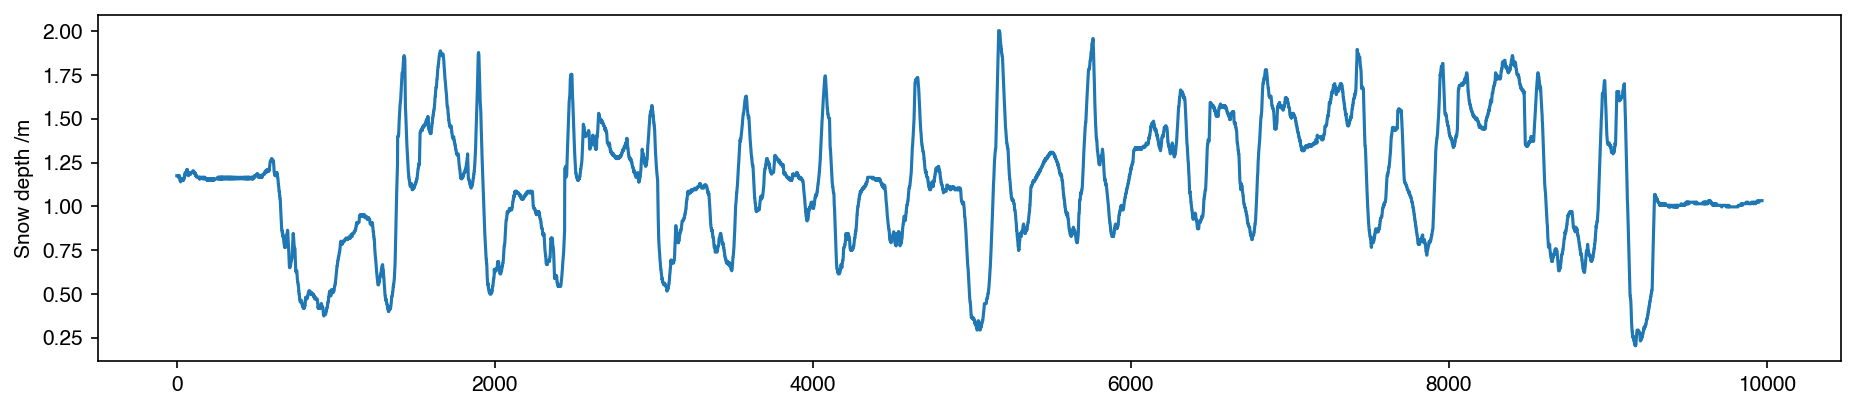

In [16]:
# TODO is this really necessary? do we ever have multiple snow pits at one site?
range_snow = np.column_stack([RADAR.range_air / np.sqrt(eps_r) for eps_r in RADAR.SP_bulk_eps_r])

RADAR.range_snow = range_snow
RADAR.PF_snow_depth_air = np.array([RADAR.range_air[RADAR.PF_bottom_interface[i]] - RADAR.range_air[RADAR.PF_top_interface[i]] for i in range(len(RADAR.PF_bottom_interface))]) / 100
RADAR.PF_snow_depth = np.array([RADAR.range_snow[RADAR.PF_bottom_interface[i], i] - RADAR.range_snow[RADAR.PF_top_interface[i], i] for i in range(len(RADAR.PF_bottom_interface))]) / 100

%matplotlib inline
fig, ax = plt.subplots(1,1, figsize=(15,3), dpi=150)
ax.plot(RADAR.PF_snow_depth)
ax.set_ylabel('Snow depth /m');

### Add uncertainties

This is the uncertainty scheme:

\begin{equation}
    \varepsilon_{\text{radar}} = \left( \varepsilon_{\text{sampling}}^2 + \varepsilon_{\text{A | S}}^2 + \varepsilon_{\text{S | G/I}}^2 \right)^{1/2}
\end{equation}

where the individual terms are:
\begin{equation}
    \varepsilon_{\text{sampling}} = \frac{\Delta t_{\text{fast}} c }{2}
\end{equation}
$\varepsilon_{\text{sampling}}$ is the error regarding where within the discrete range bin the recorded return value originates from. When sampling with a fixed time interval $\Delta t_{\text{fast}}$ (*dft* in code), we assume the center of the range bin while it could be anywhere within.

\begin{align}
        \varepsilon_{\text{A | S}} &= \frac{\Delta R_{\text{air}}}{(2 \cdot \text{SNR}_{\text{air}})^{1/2}} = \frac{\Delta R_{\text{air}}}{(2 \cdot \frac{P_\text{A | S}}{\sigma_\text{air}})^{1/2}}\\
    \varepsilon_{\text{S | G/I}} &= \frac{\Delta R_{\text{snow}}}{(2 \cdot \text{SNR}_{\text{snow}})^{1/2}}  = \frac{\Delta R_{\text{air}}}{(2 \cdot \frac{P_\text{S | G/I}}{\sigma_\text{snow}})^{1/2}}
\end{align} 


For the snow depth uncertainty $\varepsilon_{\text{snow}}$, taking into account the conversion from air range bins to an actual snow depth, we derive via Gaussian error propagation:
\begin{equation}
    \varepsilon_{\text{snow}} = \left[ \left(\frac{\varepsilon_{\text{radar}}}{\hat{\eta}_{\text{ds}}} \right)^2+ \left(\frac{h_{\text{air}}}{\hat{\eta}_{\text{ds}} }\varepsilon_{\eta_{\text{ds}}}\right)^2 \right] ^ {1/2}
\end{equation}

we additionally take the mean bias between the two measurends and the in-situ precision into account:
\begin{equation}
    \varepsilon_\text{total} = \left(\delta_\text{radar-MP}^2 + \varepsilon_\text{snow}^2 + \varepsilon_\text{MP}^2 \right) ^ {1/2}
\end{equation}


Here, we need to set the radar bandwidth [Hz] to calculate the range resolution. Additionally, we need the sampling interval *dft*:

In [17]:
RADAR.bandwidth = 3.8e9
RADAR.dft = RADAR.fasttime[1] * 1e-9

and then we run the calculation:

In [18]:
RADAR.PF_radar_uncertainty, RADAR.PF_sampling_uncertainty, RADAR.PF_top_interface_SNR, RADAR.PF_bottom_interface_SNR, RADAR.range_resolution_air, RADAR.range_resolution_snow = calculate_radar_uncertainties(RADAR, RADAR.rx_rpca[:,:], RADAR.PF_cost_maps['unbiased'])
RADAR.PF_snow_uncertainty = calculate_snow_depth_uncertainty(RADAR)
RADAR.PF_total_uncertainty = calculate_total_uncertainty(RADAR)

looking at the uncertainties:

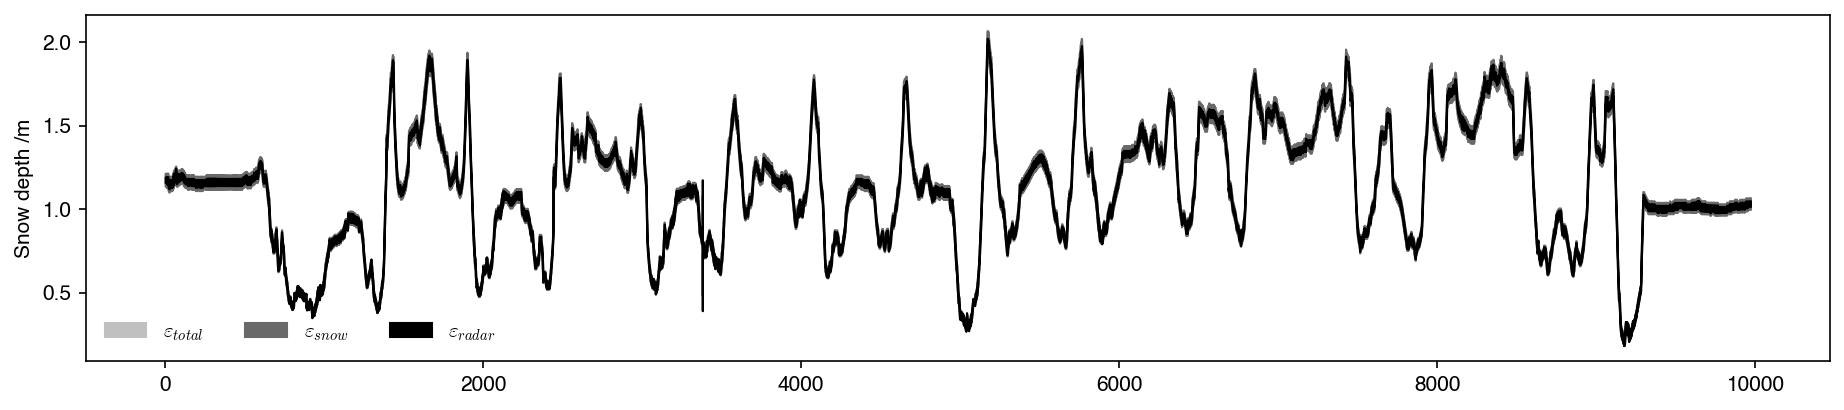

In [19]:

%matplotlib inline
fig, ax = plt.subplots(1,1, figsize=(15,3), dpi=150)
ax.fill_between(np.arange(len(RADAR.PF_snow_depth)), RADAR.PF_snow_depth - RADAR.PF_total_uncertainty, RADAR.PF_snow_depth + RADAR.PF_total_uncertainty,
                color='silver',
                label='$\\varepsilon_{total}$'
                )
ax.fill_between(np.arange(len(RADAR.PF_snow_depth)), RADAR.PF_snow_depth - RADAR.PF_snow_uncertainty, RADAR.PF_snow_depth + RADAR.PF_snow_uncertainty,
                color='dimgrey',
                label='$\\varepsilon_{snow}$'
                )
ax.fill_between(np.arange(len(RADAR.PF_snow_depth)), RADAR.PF_snow_depth - RADAR.PF_radar_uncertainty, RADAR.PF_snow_depth + RADAR.PF_radar_uncertainty,
                color='black',
                label='$\\varepsilon_{radar}$'
                )
ax.legend(frameon=False, ncol=3)
ax.set_ylabel('Snow depth /m');

### Saving to the RADAR object 

Now of course we want to save the results to the RADAR object for future use. Along with that we construct a self-described .nc file.

In [20]:
with open(RADAR.full_path, 'wb') as outp:
    pickle.dump(RADAR, outp, pickle.HIGHEST_PROTOCOL)
    
# make_nc_file(RADAR)

### Want to re-open later?

Just use *RADAR_pathfinder_viewer.py* from the command line. Since we saved everything to the RADAR object we can simply launch the clicki tool there!